# Week 5 lab: tree ensembles

AIE683 Machine Learning, Week 5.

**The problem.** A lender, an insurer or a public agency often has to make a yes/no decision from a table of
mixed columns: age, education, occupation, hours worked, capital gains. Here we use the UCI *Adult* census
data (48,842 people, 14 columns, 8 of them categorical) and predict whether a person's income exceeds
$50K. It is a stand-in for many real screening problems, and it has the typical shape of tabular data where
tree ensembles are the default strong baseline. (Keep in mind that such predictions can encode historical
bias; we come back to this when we discuss evaluation and interpretation.)

**Plan**
1. A single decision tree, and **Try it 1**: tree vs. forest.
2. What goes wrong in practice: extrapolation and misleading feature importances.
3. Modern gradient boosting in scikit-learn: `HistGradientBoostingClassifier` with native categorical
   support, early stopping and monotonic constraints.
4. RF vs. HistGB vs. XGBoost vs. LightGBM vs. CatBoost, logged to MLflow.
5. **Try it 2**: a small competition on a held-out test set.

Total runtime is about 2-4 minutes on a laptop.
*macOS note:* XGBoost and LightGBM need the OpenMP runtime (`brew install libomp`). If they cannot be
imported, the notebook skips them and says so.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"  # set before importing numpy / scikit-learn

import pathlib
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

%matplotlib inline
RANDOM_STATE = 0

/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def optional_boosters() -> dict:
    """Import XGBoost / LightGBM / CatBoost if they load on this machine."""
    libs = {}
    try:
        import xgboost
        libs["xgboost"] = xgboost
    except Exception as exc:  # XGBoostError when libomp is missing on macOS
        print("XGBoost unavailable:", type(exc).__name__, "- on macOS run `brew install libomp`")
    try:
        import lightgbm
        libs["lightgbm"] = lightgbm
    except Exception as exc:  # OSError when libomp is missing on macOS
        print("LightGBM unavailable:", type(exc).__name__, "- on macOS run `brew install libomp`")
    try:
        import catboost
        libs["catboost"] = catboost
    except Exception as exc:
        print("CatBoost unavailable:", type(exc).__name__)
    return libs

LIBS = optional_boosters()
print("available:", list(LIBS))

available: ['xgboost', 'lightgbm', 'catboost']


## Data

In [3]:
adult = fetch_openml("adult", version=2, as_frame=True)
X = adult.data.copy()
num_cols = X.select_dtypes("number").columns
X[num_cols] = X[num_cols].astype(float)  # float dtypes avoid integer-rounding issues in inspection tools
y = (adult.target == ">50K").astype(int)
print(X.shape, "positive rate:", round(y.mean(), 3))
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=RANDOM_STATE)
cat_cols = X.select_dtypes("category").columns.tolist()
X.head()

(48842, 14) positive rate: 0.239


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States
4,18.0,NaN,103497.0,Some-college,10.0,Never-married,NaN,Own-child,White,Female,0.0,0.0,30.0,United-States


Trees in scikit-learn (`DecisionTreeClassifier`, `RandomForestClassifier`) need numeric input, so we
ordinal-encode the categorical columns. For trees this is usually fine, unlike for linear models (Week 4),
because a tree can isolate any category with a few splits. Missing values are encoded as their own code.

depth-3 tree test accuracy: 0.8397


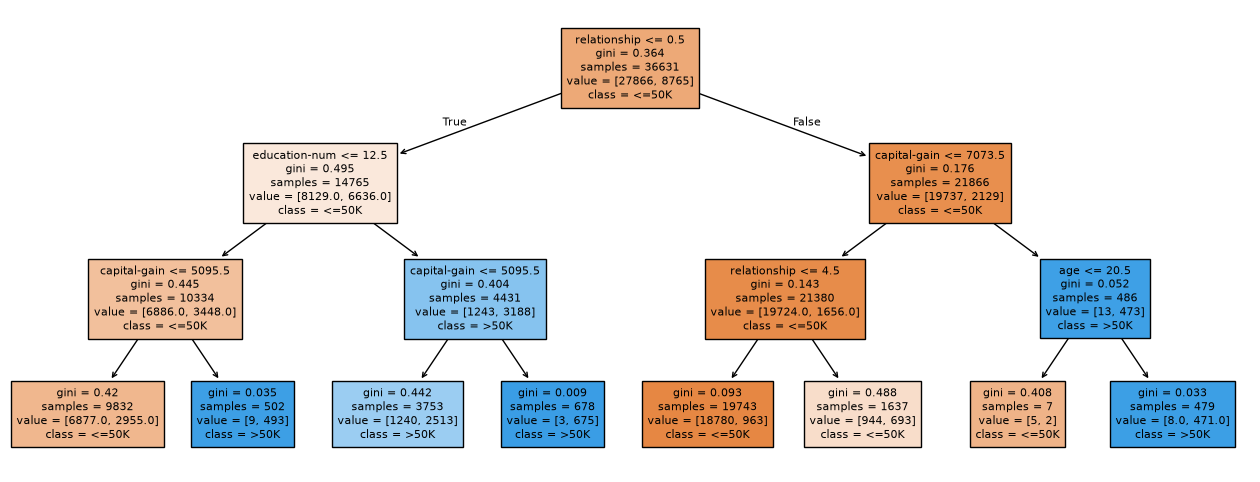

In [4]:
ordinal = make_column_transformer(
    (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1),
     make_column_selector(dtype_include="category")),
    remainder="passthrough", verbose_feature_names_out=False)

tree = make_pipeline(ordinal, DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
tree.fit(X_train, y_train)
print("depth-3 tree test accuracy:", round(tree.score(X_test, y_test), 4))

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree[-1], feature_names=tree[0].get_feature_names_out(), filled=True, ax=ax, fontsize=8,
          class_names=["<=50K", ">50K"]);

---
## Try it 1: tree vs. forest (about 10 minutes)

1. **Before running anything**, write down your prediction: which reaches the higher test accuracy,
   (a) a single decision tree whose `max_leaf_nodes` you tune with 5-fold CV, or (b) a
   `RandomForestClassifier` with default settings? By how much?
2. Complete the TODO cells: tune the tree, fit the forest, compare test accuracy and fit time.
3. Discuss: which one won, and why? Then refit the forest with `min_samples_leaf=5` (or
   `max_features=0.3`) and compare again. What does the tuned tree give you that a forest does not?

In [5]:
my_prediction = "TODO: e.g. 'forest wins by about 2 points'"
print(my_prediction)

TODO: e.g. 'forest wins by about 2 points'


In [6]:
# TODO: tune max_leaf_nodes of a single tree with 5-fold GridSearchCV on the training set.
# Suggested grid: [4, 8, 16, 32, 64, 128, 256]. Store the fitted GridSearchCV in `tree_grid`.
tree_grid = None

if tree_grid is not None:
    print("best:", tree_grid.best_params_, "test accuracy:", round(tree_grid.score(X_test, y_test), 4))

In [7]:
# TODO: fit a RandomForestClassifier (defaults, n_jobs=-1, random_state=RANDOM_STATE) inside a
# pipeline with `ordinal`; record the fit time. Store the pipeline in `forest`.
forest = None

if forest is not None:
    print("forest test accuracy:", round(forest.score(X_test, y_test), 4))

---
## What goes wrong in practice

### Pitfall 1: trees cannot extrapolate
Historical RAM prices (\$/MB, log scale). We train on years before 2000 and predict afterwards.

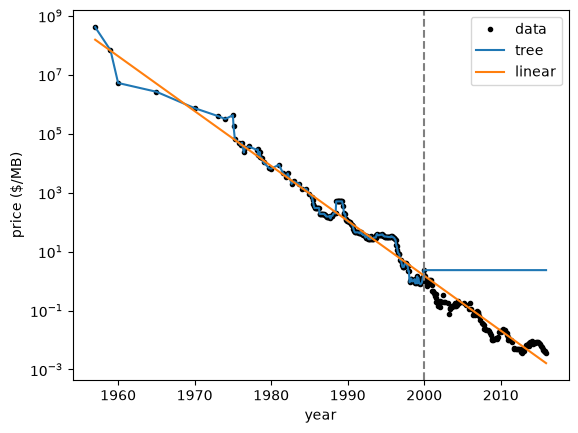

In [8]:
ram = pd.read_csv("ram_price.csv")

train_ram, test_ram = ram[ram.date < 2000], ram[ram.date >= 2000]
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
tree_ram = DecisionTreeRegressor().fit(train_ram[["date"]], np.log(train_ram.price))
lin_ram = LinearRegression().fit(train_ram[["date"]], np.log(train_ram.price))

plt.semilogy(ram.date, ram.price, 'k.', label="data")
plt.semilogy(ram.date, np.exp(tree_ram.predict(ram[["date"]])), label="tree")
plt.semilogy(ram.date, np.exp(lin_ram.predict(ram[["date"]])), label="linear")
plt.axvline(2000, ls="--", c="gray")
plt.xlabel("year"); plt.ylabel("price ($/MB)"); plt.legend();

The tree predicts a constant after 2000: the value of the last leaf. Forests and boosting inherit this.
If the target has a trend, model the change (or the ratio to a baseline) instead of the level.

### Pitfall 2: impurity-based importances reward noise
We add a column of random IDs, pure noise with many unique values, and compare the forest's
`feature_importances_` (computed on training data) with permutation importance on held-out data.
Week 9 covers interpretation in depth; here we only want the warning.

In [9]:
from sklearn.inspection import permutation_importance

rng = np.random.RandomState(RANDOM_STATE)
X_train_noise = X_train.assign(random_id=rng.randint(0, 100_000, len(X_train)))
X_test_noise = X_test.assign(random_id=rng.randint(0, 100_000, len(X_test)))

rf_noise = make_pipeline(ordinal, RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                         random_state=RANDOM_STATE))
rf_noise.fit(X_train_noise, y_train)
names = rf_noise[0].get_feature_names_out()
mdi = pd.Series(rf_noise[-1].feature_importances_, index=names)

sub = X_test_noise.sample(3000, random_state=RANDOM_STATE)
perm = permutation_importance(rf_noise, sub, y_test.loc[sub.index], n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm = pd.Series(perm.importances_mean, index=sub.columns)

pd.DataFrame({"impurity (train)": mdi, "permutation (test)": perm}).sort_values(
    "impurity (train)", ascending=False).round(3).head(8)

,impurity (train),permutation (test)
fnlwgt,0.121,0.004
random_id,0.120,0.000
age,0.119,0.017
capital-gain,0.115,0.040
relationship,0.105,0.026
education-num,0.084,0.034
hours-per-week,0.072,0.009
marital-status,0.066,0.006


`random_id` and `fnlwgt` (a survey weight, nearly unique per person) rank near the top by impurity, yet
their permutation importance on test data is about zero. Fully grown trees use high-cardinality columns
to memorize the training set.

---
## Modern gradient boosting in scikit-learn

`HistGradientBoostingClassifier` bins every feature into at most 255 bins, which makes split finding fast.
With `categorical_features="from_dtype"` (the default) it treats pandas `category` columns natively,
so no encoder is needed, and it handles missing values natively.

In [10]:
hgb = HistGradientBoostingClassifier(max_iter=1000, learning_rate=0.1, early_stopping=True,
                                     n_iter_no_change=20, random_state=RANDOM_STATE)
tick = perf_counter()
hgb.fit(X_train, y_train)
print(f"fit {perf_counter() - tick:.1f}s, iterations used: {hgb.n_iter_} of 1000")
print("categorical features detected:", list(X_train.columns[hgb.is_categorical_]))
print("test accuracy:", round(hgb.score(X_test, y_test), 4),
      " ROC AUC:", round(roc_auc_score(y_test, hgb.predict_proba(X_test)[:, 1]), 4))

fit 0.4s, iterations used: 162 of 1000
categorical features detected: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
test accuracy: 0.8722  ROC AUC: 0.9278


Early stopping held out 10% of the training data (`validation_fraction=0.1`) and stopped once the
validation loss had not improved for 20 iterations. The test set was never used for this decision.

**Monotonic constraints.** Domain knowledge sometimes says a prediction must not decrease when a feature
increases (e.g. predicted income vs. years of education, all else equal). `monotonic_cst` enforces it:
`1` increasing, `-1` decreasing, `0` unconstrained; with a DataFrame you can pass a dict by column name.

constrained test ROC AUC: 0.923


/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/inspection/_plot/partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/inspection/_plot/partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


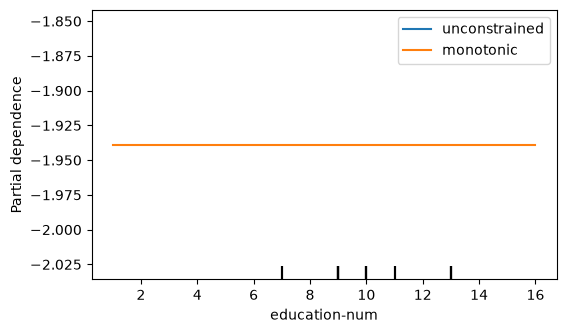

In [11]:
hgb_mono = HistGradientBoostingClassifier(
    monotonic_cst={"education-num": 1, "capital-gain": 1}, random_state=RANDOM_STATE)
hgb_mono.fit(X_train, y_train)
print("constrained test ROC AUC:", round(roc_auc_score(y_test, hgb_mono.predict_proba(X_test)[:, 1]), 4))

from sklearn.inspection import PartialDependenceDisplay
sample = X_train.sample(2000, random_state=0)
fig, ax = plt.subplots(figsize=(6, 3.5))
disp = PartialDependenceDisplay.from_estimator(hgb, sample, ["education-num"], ax=ax,
                                               line_kw={"label": "unconstrained"})
PartialDependenceDisplay.from_estimator(hgb_mono, sample, ["education-num"], ax=disp.axes_,
                                        line_kw={"label": "monotonic", "color": "tab:orange"})
disp.axes_[0, 0].legend();

---
## Comparing libraries, logged to MLflow

One run per model in the experiment `week05-tree-ensembles`. Each library handles categorical columns
differently:

- scikit-learn RF: needs an encoder (we use `OrdinalEncoder`).
- `HistGradientBoostingClassifier`: native, from the pandas `category` dtype.
- XGBoost: native with `enable_categorical=True` and `tree_method="hist"`.
- LightGBM: native, uses the pandas `category` dtype automatically.
- CatBoost: pass `cat_features`; categories must be strings without missing values.

Settings are close to defaults and not tuned, so read the table as "what you get out of the box", not as a
ranking of the libraries.

In [12]:
def catboost_frame(df: pd.DataFrame) -> pd.DataFrame:
    """CatBoost wants string categories without NaN."""
    out = df.copy()
    for c in cat_cols:
        out[c] = out[c].cat.add_categories("missing").fillna("missing").astype(str)
    return out

candidates = {
    "RandomForest": (make_pipeline(ordinal, RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE)),
        {"n_estimators": 300, "min_samples_leaf": 2}, X_train, X_test),
    "HistGradientBoosting": (HistGradientBoostingClassifier(
        max_iter=1000, learning_rate=0.1, early_stopping=True, n_iter_no_change=20,
        random_state=RANDOM_STATE),
        {"max_iter": 1000, "learning_rate": 0.1, "early_stopping": True}, X_train, X_test),
}
if "xgboost" in LIBS:
    candidates["XGBoost"] = (LIBS["xgboost"].XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6, tree_method="hist",
        enable_categorical=True, random_state=RANDOM_STATE),
        {"n_estimators": 300, "learning_rate": 0.1, "max_depth": 6}, X_train, X_test)
if "lightgbm" in LIBS:
    candidates["LightGBM"] = (LIBS["lightgbm"].LGBMClassifier(
        n_estimators=300, learning_rate=0.1, num_leaves=31, verbose=-1, random_state=RANDOM_STATE),
        {"n_estimators": 300, "learning_rate": 0.1, "num_leaves": 31}, X_train, X_test)
if "catboost" in LIBS:
    candidates["CatBoost"] = (LIBS["catboost"].CatBoostClassifier(
        iterations=300, learning_rate=0.1, depth=6, cat_features=cat_cols, verbose=0,
        random_seed=RANDOM_STATE, allow_writing_files=False),
        {"iterations": 300, "learning_rate": 0.1, "depth": 6},
        catboost_frame(X_train), catboost_frame(X_test))
list(candidates)

['RandomForest', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']

In [13]:
mlflow.set_experiment("week05-tree-ensembles")

for name, (model, params, Xtr, Xte) in candidates.items():
    with mlflow.start_run(run_name=name):
        tick = perf_counter()
        model.fit(Xtr, y_train)
        fit_time = perf_counter() - tick
        proba = model.predict_proba(Xte)[:, 1]
        mlflow.log_param("model", name)
        mlflow.log_params(params)
        mlflow.log_metrics({"test_accuracy": accuracy_score(y_test, proba > 0.5),
                            "test_roc_auc": roc_auc_score(y_test, proba),
                            "fit_time_s": fit_time})

runs = mlflow.search_runs(experiment_names=["week05-tree-ensembles"])
cols = ["tags.mlflow.runName", "metrics.test_roc_auc", "metrics.test_accuracy", "metrics.fit_time_s"]
runs[cols].drop_duplicates("tags.mlflow.runName").sort_values("metrics.test_roc_auc", ascending=False).round(4)

2026/09/30 00:02:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/30 00:02:36 INFO mlflow.store.db.utils: Updating database tables


2026/09/30 00:02:37 INFO mlflow.tracking.fluent: Experiment with name 'week05-tree-ensembles' does not exist. Creating a new experiment.


,tags.mlflow.runName,metrics.test_roc_auc,metrics.test_accuracy,metrics.fit_time_s
0,CatBoost,0.9290,0.8728,3.6665
2,XGBoost,0.9288,0.8726,0.4595
3,HistGradientBoosting,0.9278,0.8722,0.4085
1,LightGBM,0.9278,0.8701,1.3617
4,RandomForest,0.9160,0.8664,1.0180


Run `uv run mlflow ui` from this folder to browse the runs. Note that the four boosting libraries end
up within a few thousandths of ROC AUC of each other; the gap to the random forest is larger.

---
## Try it 2: a small competition (about 15 minutes)

Goal: the highest **test ROC AUC** with `HistGradientBoostingClassifier`.

Rules:
1. Choose hyperparameters using **cross-validation on the training set only**
   (`cross_val_score(..., scoring="roc_auc", cv=5)`). Touch `X_test` exactly once, for your final model.
2. Log every CV attempt as an MLflow run in the experiment `week05-competition` (params + `cv_roc_auc`).
3. Useful knobs: `learning_rate`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization`,
   `max_features`, `max_iter` with `early_stopping=True`.

At the end we compare test scores in class. Question to think about: how large must a difference in
test ROC AUC be before you believe it? (Week 8 answers this properly.)

In [14]:
mlflow.set_experiment("week05-competition")

def cv_attempt(**params) -> float:
    """Cross-validate one HistGradientBoosting configuration and log it to MLflow."""
    model = HistGradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    score = cross_val_score(model, X_train, y_train, scoring="roc_auc", cv=5).mean()
    with mlflow.start_run():
        mlflow.log_params(params)
        mlflow.log_metric("cv_roc_auc", score)
    print(params, round(score, 4))
    return score

_ = cv_attempt()  # the default configuration as a baseline
# TODO: try a few configurations, e.g.
# cv_attempt(learning_rate=0.05, max_iter=500, early_stopping=True)

2026/09/30 00:02:44 INFO mlflow.tracking.fluent: Experiment with name 'week05-competition' does not exist. Creating a new experiment.


{} 0.9276


In [15]:
# TODO: put your chosen configuration here, fit on the full training set, evaluate ONCE on the test set.
best_params = {}
final = HistGradientBoostingClassifier(random_state=RANDOM_STATE, **best_params).fit(X_train, y_train)
print("final test ROC AUC:", round(roc_auc_score(y_test, final.predict_proba(X_test)[:, 1]), 4))

final test ROC AUC: 0.9281
